In [39]:
import random 
import matplotlib.pyplot as plt
import numpy as np
#this code is intended to evaluate the potential evolution of the Meowl from the microraptor 

""""
Phase One:
Traits: {biteforce, forwardeyes, legwings, retractableclaws, legstrength, eyesize, silentflight, taillength, shimmer, eartufts}
These traits are picked based on the working hypothesis for the microraptor as a glider that leans into:
aroboral gliding, terristrial feeding, arboral escape. The microraptor is further pushed to work towards a nocturnal/crepuscular lifestyle
due to the increasing efficiency of the early birds in the current niche that both the microraptors and the birds were occupying.
"""

#Putting down a baseline so the initial population is not that crazy
canon_microraptor= {
    'bite_force': 0.3, #The bite force was not that strong
    'forward_eyes': 0.4, #It was more predator-like but also not entirely forward-facing
    'leg_wings': 1, #It had them.
    'retractable_claws': 0, # Non-existent. They were exposed all the time.
    'leg_strength': 0.5, #Strong enough for climbing and killing small prey only.
    'eye_size': 0.4, #No large eyes
    'silent_flight': 0.3, #had feathers but not for silent flight or glide
    'tail_length': 0.9, #the tail was long and stiff
    'shimmer': 1, # It's confirmed they were shimmery and iridescent 
    'ear_tufts': 0, #They did not have them.
    'body_mass': .45, #This is on a scale where (0= Colugo 1= Fussa). 
                     #The rationale behind this scale is that they occupy similar niches to the microraptor's working hypothesis.
    'snout_size': .45, #Where 0=Owl, 1=Fossa
    'wings_length': .65, # moderate wing length, where wing=0 is a vestigial wing.
    'hearing': .5, #good but not specialized. 1 = Owl level
    
    'whiskers': .1 #the fossile record does not provide evidence. But judging from modern birds, it theoritically could be possible. 
                   #It's important to note that these are "rectal bristles" but for convenience, we here use "whiskers"
    }

#Creating a naturalistic variation that the population could differ in (not counting mutations)
variation= {
    'bite_force': 0.05, 
    'forward_eyes': 0.05, 
    'leg_wings': .04, #lower than the standard .05 because it is one of the main characteristics of the species
    'retractable_claws': .01,  #Very low because this is an unnecessary trait for the canon microraptor at this stage.
    'leg_strength': 0.05,
    'eye_size': 0.04, #The same concept as the retractable claws
    'silent_flight': 0.05,
    'tail_length': 0.05, 
    'shimmer': .05,  
    'ear_tufts': .04, #The same concept as the retractable claws
    'body_mass': .03,    # Body mass has relatively low natural variation within a species
                         # Individual Microraptors were probably fairly similar in mass
    'snout_size': .04, 
    'wings_length': .04, 
    'hearing': .04,
    'whiskers': .04 
    }

#This creates an individual based on the canon microraptor that only variates in the possible realms (not counting mutations)
def create_individual():
    individual= {}
    for trait, baseline in canon_microraptor.items():
        possible_variation=variation[trait]
        value= baseline + random.uniform(-possible_variation,possible_variation)
        individual[trait] = max(0, min(1, value)) #Ensures the trait stays between 0 and 1. 
                                                  #This is not necessary here since the variation is limited but for future use.        
    return individual

#Creating the function that creates a population of a desired size.
def create_population(size):
    return [create_individual() for _ in range(size)]

#The fitness function. Basically the orchestrator of the symphony that is evolution
#First, we define the main components: [hunting, escape, longevity, reporoduction]

#Here, we start with the hunting function
def hunting_score(individual):
    '''
    This function calculates the hunting score for the individual based on the environemnt of the microraptor
    It's important to note that the traits that are multiplied are dependant and the traits that are added are independant.
    The main components: [ambush_prep, vision, approach, kill_potential]
    '''
        #Ambush Prep
        #You need to position yourself in order to set up the ambush
    climbing_contribution=(
        (individual['leg_strength']*0.7) 
        * (individual['body_mass']*0.35     #If you increase leg strength, you MUST increase body mass!
        * (1+individual['retractable_claws']* .4)) 
        * (1-individual['leg_wings']* 0.4) 
        * (1-individual['tail_length']*.4)
        )
    #Shining under the moonlight is not ideal
    coloration_penalty= (1-individual['shimmer']*.4)
    
    
    ambush_prep= climbing_contribution * coloration_penalty

    
    #Vision
    # Eye size captures more light and gives better vision. Forward-facing eyes give tunnel vision and better judgment.
    vision= individual['eye_size']*individual['forward_eyes']
    # Bigger snout blocks vision, smaller one makes it better
    snout_effect = 1 + ((0.5 - individual['snout_size']) * 0.5) #it penalizes and also rewards depending on the size
    
    vision *= snout_effect


    #Approach    
    silent_contribution= (1 + individual['silent_flight'] * 0.3)  # bonus for silence
    iridescence_penalty= (1 - individual['shimmer']* 0.4)
    
    #Here, we define two different competing approaches based on how the traits differ. 
    #First, the gliding approach which is known for the Microraptor at the time.
    #Essentially: gliding = “I steer onto the prey”, pouncing = “I launch myself onto the prey”

    #Gliding
    gliding_approach = (
        (individual['leg_wings'] + individual['wings_length']) 
        * (1 + individual['tail_length'] * 0.2)
        * (1 - individual['body_mass'] * 0.6)
        * (1- individual['ear_tufts']*.07)
        * (1+ individual['whiskers']*.3)
        * silent_contribution
        * iridescence_penalty
    )
    
    #Pouncing
    pounce_contribution = individual['body_mass'] * individual['leg_strength'] * (1+ individual['whiskers']*.3) *1.3
    pouncing_approach = pounce_contribution * silent_contribution * iridescence_penalty

    #The approach with the higher score is picked. 
    approach = max(gliding_approach, pouncing_approach) 
   
    #Kill Potential
    leg_contribution  = individual['leg_strength'] *(1-individual['leg_wings']*.4)* (1+ individual['retractable_claws']*0.4) #sharper claws
    bite_contribution = individual['bite_force']   *1.6
    size_contribution = individual['body_mass']    * 0.6 #was adjusted from .4 to .6 because the body mass evolution was absurd.
    snout_penalty     = (1 - individual['snout_size'] * 0.4)
    close_range_precision= (1+ individual['whiskers']*.4)

    kill_potential = ((leg_contribution * bite_contribution * close_range_precision) + size_contribution) * snout_penalty
    
    hunting_value= ((ambush_prep*approach) + (vision*.6)) * (kill_potential*1.3) #vision was toned down because it was inflating hard
                                                                                 #Kill potential needed to have increased weight due to absurd scores
    return  {
        "pouncing_approach":pouncing_approach,
        "gliding_approach": gliding_approach,
        "ambush_prep": ambush_prep,
        "vision": vision,
        "approach": approach,
        "kill_potential": kill_potential,
        "hunting_value": hunting_value
    }
#Now, the Escape function
def escape_score(individual):
    '''
    This function calculates the escape score for the individual based on the environemnt of the microraptor and the environmental pressures.
    It's important to note that the traits that are multiplied are dependant and the traits that are added are independant.
    The main components: [climbing, running, vigilance, endurance, fighting_capability, agility, camouflage]
    '''

    #Climbing: Given that we have already made a variable for it from the hunting function, we can use that.
    climbing_contribution=(
        ((individual['leg_strength']*0.7) 
        * (1+individual['retractable_claws']* .4)) 
        * (1-individual['leg_wings']* 0.4) 
        * (1-individual['tail_length']*.4)
        )
    #Running
    running_contribution=(
        individual['leg_strength']
        *(1 + individual['retractable_claws'] * 0.2)
        *(1 - individual['wings_length'] * 0.3)
        *(1 - individual['body_mass'] * 0.4) #adjusted due to absurd evolution
        *(1-individual['tail_length']*0.4)
        *(1-individual['leg_wings']*0.4)
        #more aerodynamics and difficult maintainance, less speed
    )

    #Vigilance
  
    vision_contribution= (
        individual['eye_size']
        *(1 - individual['forward_eyes']*.3) #Bigger eyes are useful, but forward facing eyes retrict the vision field a bit
        
        *(1 - individual['body_mass'] * 0.3) #Bigger animals typically have less vigilance 
    )
    hearing_contribution= (individual['hearing']*.5) #Very important, even more than vision n in this case!
    
    vigilance_contribution= (vision_contribution+hearing_contribution)*.3 #This is an addition because they are dependant
                                                                       #This had to be weighted down because of how it was inflating the model.
    
    #Endurance
    #While it might not be that important to the microraptor at this stage, it has to be added for the future.
    endurance_contribution=(
        (individual['body_mass'] * individual['leg_strength'])
        * (1 - individual['wings_length'] * 0.3)
        * (1 - individual['leg_wings'] * 0.2)
        * (1 - individual['tail_length'] * 0.2)
        * (1 - individual['silent_flight'] * 0.1) #More surface area
    )
    
    #Fighting_Capability
    #Again, the canon microraptor would rather try to escape than fight. But as it evolves, it will have this opportunity
    fighting_capability=(
        (
        (1+individual['bite_force']*.5) 
        *(1 - individual['snout_size'] * 0.3) #bite force negativally correlated with snout size.
        *(1 + individual['retractable_claws'] * 0.4)#sharper claws

        #Borrowing the endurance formula because it just makes sense for fighting as well
        *((individual['body_mass'] * individual['leg_strength'])
        * (1 - individual['wings_length'] * 0.3)
        * (1 - individual['leg_wings'] * 0.2)
        * (1 - individual['tail_length'] * 0.2)
        * (1 + individual['whiskers'] * 0.2) #close range precision
        ))
        #Vision is an independant benefit
        + (individual['eye_size'] * individual['forward_eyes'] * 0.2) 
        )
    
    fighting_capability= fighting_capability*0.3 #this is weighted down due to the nature of the environmental pressures and the current
                                                 #status of the microraptor. It cannot possibly fight, so, fighting is rewarded but not strongly.
   
    #Agility
    #How good the creature moves and just overall the quality of the movement. 
    #Important to note since endurance is the duration of which the movements can be dragged out.
    agility_contribution=(
        (individual['leg_strength']
        *(1 - individual['body_mass'] * 0.6)
        *(1 - individual['tail_length'] * 0.4) #While longer flexible tails are nice for agility (ex:Fossa), the microraptor's tail 
                                               #is quite stiff and feathered. So, It is more of a disadvantage
                                               #Moreover, evolution would probably push for a shorter tail rather than a reconstruction of the tail.
        
        *(1 + individual['retractable_claws'] * 0.4) #Good for redirection (ex:cheetahs)
        *(1 + ((0.35 - individual['wings_length']) * 0.3)) #Wing length could help with agility when at a certain length. (ex:Roadrunner)
        *(1 + individual['whiskers'] * 0.2) #Close range movements 
        *(1 + individual['silent_flight'] * 0.1)) #slightly more flexible and hence sliiiiightly more agile
        
        + (individual['eye_size'] * individual['forward_eyes'] * 0.2) #Again, vision as an independant benefit
    )

    #Camouflage
    #This one is interesting because  it can belong to active escape and also passive threat prevention or "passive escape"
    #Here, we add it to the active escape but with a lower weight because it does help BUT slightly. 
    camouflage_contribution=(
        ( 1 + individual['ear_tufts'] * 0.5) #Ear tufts help greatly with breaking the silloute and hence camouflage.
        *(1 - individual['shimmer']*0.8) #Very very bad for camouflage. Especially when the niche expands further into longer day-time roosting
        
        *(1 - individual['body_mass'] * 0.2) #smaller=less detectable
        *(1 - individual['wings_length'] * 0.15)
        *(1 - individual['leg_wings'] * 0.1)
        
        *(1 + individual['silent_flight'] * 0.3) #velvet feathers that are needed for silent flight, absorb light. Meaning, less shimmer
      
    )
    camouflage_contribution= (camouflage_contribution*0.3) #As mentioned earlier, its weight is lowered for the "active_escape"
                                                           #Notice how this terminology is not explicitly said in the code but inferred. 

    #Escape Score Calculations
    physical_escape = (
         ((climbing_contribution + running_contribution)/2) #This is because climbing and running may be deflated through multiplication even though they are dependant.
                                  #So, we normalize.
       
        *(1 + endurance_contribution * 0.3) #Same idea as the fighting and camouflage.
        *(1 + agility_contribution * 0.3)
        *1.3                                #This is to inflate it a bit, since the model was being deflated by the normalization.
    )
    
    escape_value=(
    physical_escape
    + (vigilance_contribution)
    + (fighting_capability)      # already weighted down internally
    + (camouflage_contribution)  # already weighted down internally
    )
    escape_dict ={
        "physical_escape":physical_escape,
        "climbing": climbing_contribution,
        "running": running_contribution,
        "vigilance": vigilance_contribution,
        "endurance": endurance_contribution,
        "fighting_capability": fighting_capability,
        "agility": agility_contribution,
        "camouflage": camouflage_contribution,
        "escape_value": escape_value
        }

    return escape_dict

#Now, mortality rate!

def mortality_score(individual):
    #we calculate the hunting score in order to use it in the longevity calculation
    #This could be redundant in nature because we calculate it twice. However, currently, the structure of the functions is not clear yet.
    
    hunt_for_life= hunting_score(individual) 
    
    #Metabolic and Biological Constraints
    metabolic_capacity=(individual['body_mass'] ** 0.75)  # Kleiber's law!
    body_maintenance = individual['body_mass'] * 0.4 #Maintaining the body requires energy 
                                                     #Was snatched from .6 to .4 due to absordity in the evolved population
    
    #Better hunters, get better food.
    food_intake = (hunt_for_life["hunting_value"] *.6) 
    #Escape score
    escape_for_life= escape_score(individual)
    
    #Camouflage as taken from the escape. This is to avoid the low weight that was put on it then. (Passive_escape)
    camouflage_contribution=(
        
        (1 + individual['ear_tufts'] * 0.5) #Ear tufts help greatly with breaking the silloute and hence camouflage.
        *(1 - individual['shimmer']*0.8) #Very very bad for camouflage. Especially when the niche expands further into longer day-time roosting
        
        *(1 - individual['body_mass'] * 0.2) #smaller=less detectable
        *(1 - individual['wings_length'] * 0.15)
        *(1 - individual['leg_wings'] * 0.1)
        
        *(1 + individual['silent_flight'] * 0.3)) #velvet feathers that are needed for silent flight, absorb light. Meaning, less shimmer

    #the more you escape predators, the longer you live
    predation_survival=(
        escape_for_life['escape_value']*.5
        +(camouflage_contribution*.6))

    #Each trait costs a certain amount/energy/token. The more structural, and complex such as eye size and the neurons required for it,
    #the more expensive this trait gets.
    #The costs initially were too high and the canon microraptor was literally just dying which is not true canonically.
    #Hence, they were adjusted in order to make the model act more biologically correct.
    
    trait_costs =(
      
      # Neural tissue — superlinear because wiring more neurons and maintaining
      # larger sensory organs costs disproportionately more energy at extremes
      individual['eye_size']          ** 1.5 * 0.12 +  # retinal + visual cortex; most expensive sensory organ
      individual['forward_eyes']      ** 1.5 * 0.02 +  # orbital muscle complexity for binocular convergence
      individual['hearing']           ** 1.5 * 0.04 +  # cochlear hair cells + auditory processing cortex
      individual['whiskers']          ** 1.5 * 0.03 +  # dense sensory nerve clusters at follicle base
    
      # Structural tissue — building and maintaining physical structures also
      # scales superlinearly: larger wings need stronger attachment points,
      # more powerful muscles need more tendon reinforcement, etc.
      individual['wings_length']      ** 1.5 * 0.08 +  # primary feather shafts + pectoral muscle anchoring
      individual['leg_wings']         ** 1.5 * 0.06 +  # secondary feathered surface on hindlimb
      individual['bite_force']        ** 1.5 * 0.05 +  # jaw musculature + skull reinforcement
      individual['leg_strength']      ** 1.5 * 0.05 +  # leg musculature + tendon load capacity
      individual['retractable_claws'] ** 1.5 * 0.04 +  # flexor tendon + retraction ligament system
      individual['tail_length']       ** 1.5 * 0.03 +  # tail musculature + feather regeneration
      individual['silent_flight']     ** 1.5 * 0.03 +  # specialized velvet microstructure on every feather
    
      # Skeletal/cartilage — cheaper but still superlinear because extreme
      # snout reduction requires facial bone remodeling
      individual['snout_size']        ** 1.5 * 0.02 +  # bone + cartilage maintenance; penalizes extremes in both directions
    
      # Cheap tissue — feather-based traits cost little individually
      # but still get more expensive at full expression
      individual['ear_tufts']         ** 1.5 * 0.01 +  # simple modified feathers; cheap but not free
      individual['shimmer']           ** 1.5 * 0.015 +  # iridescent melanosome arrays; moderately expensive to maintain
    
      # Body mass — fundamental metabolic cost; superlinear because larger
      # animals require disproportionately more food, thermoregulation, and
      # cardiac output (Kleiber's law already captures some of this,
      # but this term captures the tissue maintenance component separately)
      individual['body_mass']         ** 1.5 * 0.06
        )

    #Now, of course, mortality rate depends on so many other stuff such as disease resistance and all BUT... This is honestly 
    #out of the scope of this lil project. I haven't slept in 500 years. 
    #>"WAKE UP, MARK... WHAT WILL YOU HAVE AFTER 500 YEARS???"
    #>"Meowl, dad... Meowl."

    #Adding a break on how LOW the body mass can go. Because after testing the evolution, the body mass dropped terribly.
    #It dropped even less than the canon microraptor which should not happen bioligically.
    mass_viability = 1.0 if individual['body_mass'] >= 0.30 else (individual['body_mass'] / 0.15) ** 2
    
    total_income= metabolic_capacity + food_intake + predation_survival
    total_costs= body_maintenance + trait_costs
    balance = (total_income - total_costs)*mass_viability
    return{
                'metabolic_capacity': metabolic_capacity,
        'food_income':        food_intake,
        'predation_survival': predation_survival,
        'trait_costs':        trait_costs,
        'mortality_value':    balance
    }

    #It's important to note that the hunting score for the canon microraptor is quite low because of the nature of the hunt.
    #the environment as described here is pushing the microraptor towards a nocturnal lifestyle.
    #Hence, it is natural that it would struggle at the canon-level.

#NOW, 
def reproductivity_score(individual):
    sex_appeal=(
        individual["shimmer"]*0.6
        +individual['tail_length'] * 0.4
        +individual['body_mass']*.6 #went up from .4 due to absurdity
        +individual['leg_wings'] * 0.2
        +individual['wings_length'] * 0.2
    )
    hunt_for_reproduction= hunting_score(individual)
    mortality_for_reproduction= mortality_score(individual)
    offspring_viability = (
        hunt_for_reproduction['hunting_value'] * 0.6 +  # feeding offspring
        +individual['leg_strength']     * 0.4 +  # defending territory
        +individual['body_mass']        * 0.3 +  # nest site defense
        +mortality_for_reproduction['mortality_value']   * 0.5    # living long enough for multiple seasons
    )
    
    reproduction_value = (
        sex_appeal    * 0.5 +
        offspring_viability * 0.5
    )

    return{
        "sex_appeal": sex_appeal,
        "offspring_viability": offspring_viability,
        "reproduction_value": reproduction_value
    }

stage_one = {
    'hunting_importance':      0.35,  # nocturnal hunting developing
    'escape_importance':       0.30,  # tree escape critical
    'mortality_importance':    0.45,  # metabolic sustainability
    'reproduction_importance': 0.10}  # least critical at this stage

#Biological Constraints and Dependancies----------------------------------------
def trait_viability(individual):
    """
    Returns a multiplier (0-1) that penalizes biologically impossible trait combinations.
    1.0 = fully viable, 0.0 = impossible combination.
    
    Dependency map:
    mass ──────────────→ leg_strength, bite_force, wings_length, leg_wings, hearing
    leg_strength ──────→ retractable_claws
    wings_length ──────→ silent_flight
    eye_size ──────────→ forward_eyes
    forward_eyes ──────→ whiskers
    shimmer ←──conflict─→ silent_flight
    leg_wings ←─conflict─→ leg_strength
    """
    penalties = []

    # --- Mass dependencies ---
    # Can't have strong legs without mass to anchor the muscle
    leg_mass_required = individual['leg_strength'] * 0.6
    penalties.append(min(1.0, individual['body_mass'] / leg_mass_required) if leg_mass_required > 0 else 1.0)

    # Can't have strong bite without structural mass to support jaw musculature
    bite_mass_required = individual['bite_force'] * 0.5
    penalties.append(min(1.0, individual['body_mass'] / bite_mass_required) if bite_mass_required > 0 else 1.0)

    # Long wings require pectoral muscle anchoring — needs mass
    wing_mass_required = individual['wings_length'] * 0.4
    penalties.append(min(1.0, individual['body_mass'] / wing_mass_required) if wing_mass_required > 0 else 1.0)

    # Hindlimb feathered surfaces add structural load — needs mass
    legwing_mass_required = individual['leg_wings'] * 0.4
    penalties.append(min(1.0, individual['body_mass'] / legwing_mass_required) if legwing_mass_required > 0 else 1.0)

    # Cochlear structures and auditory cortex are expensive — needs mass
    hearing_mass_required = individual['hearing'] * 0.4
    penalties.append(min(1.0, individual['body_mass'] / hearing_mass_required) if hearing_mass_required > 0 else 1.0)

    # --- Leg strength dependencies ---
    # Retractable claws need leg strength to operate the flexor tendon system
    claw_leg_required = individual['retractable_claws'] * 0.7
    penalties.append(min(1.0, individual['leg_strength'] / claw_leg_required) if claw_leg_required > 0 else 1.0)

    # --- Wing length dependencies ---
    # Silent flight specializes feather microstructure — needs the surface area first
    silent_wing_required = individual['silent_flight'] * 0.6
    penalties.append(min(1.0, individual['wings_length'] / silent_wing_required) if silent_wing_required > 0 else 1.0)

    # --- Eye dependencies ---
    # Binocular convergence requires sufficiently large eyes
    forward_eye_required = individual['forward_eyes'] * 0.7
    penalties.append(min(1.0, individual['eye_size'] / forward_eye_required) if forward_eye_required > 0 else 1.0)

    # Whiskers as close-range precision tools only make sense with forward-facing predator vision
    whisker_eye_required = individual['whiskers'] * 0.6
    penalties.append(min(1.0, individual['forward_eyes'] / whisker_eye_required) if whisker_eye_required > 0 else 1.0)

    # --- Conflicts (mutual exclusivity penalties) ---
    # Iridescent melanosomes and velvet microstructure are mutually exclusive feather architectures
    shimmer_silent_conflict = 1.0 - (individual['shimmer'] * individual['silent_flight'] * 0.8)
    penalties.append(max(0.0, shimmer_silent_conflict))

    # Feathered hindlimbs physically restrict leg muscle development
    legwing_strength_conflict = 1.0 - (individual['leg_wings'] * individual['leg_strength'] * 0.6)
    penalties.append(max(0.0, legwing_strength_conflict))

    return min(penalties)  # weakest link bottlenecks overall viability
#-------------------------------------------------------------------------------------------------------------

#The Fitness Function!
def fitness(individual, environment):
    viability = trait_viability(individual)
    hunt         = hunting_score(individual)
    escape       = escape_score(individual)
    mortality    = mortality_score(individual)
    reproduction = reproductivity_score(individual)

    score = (
        (hunt['hunting_value'] )   * environment['hunting_importance']     +
        (escape['escape_value']) * environment['escape_importance']      +
        (mortality['mortality_value'])   * environment['mortality_importance']   +
        (reproduction['reproduction_value']) * environment['reproduction_importance']
    ) *viability # it punishes the impossible combinations

    return{
        "fitness_score":score,
        "hunting_score":hunt,
        "escape_score": escape,
        "mortality_score": mortality,
        "reproductivity_score":reproduction
    
    }

In [35]:
#-------------------------The Algorithm Functions------------------------------#

#Here, I define the select function based on tournament selection
#Number of parents should be the population size/2 in order to refill the population
def select(population, number_of_parents, tournament_size=3):
    
    #Preparing the parents lounge
    selected_parents=[] 
    for _ in range(number_of_parents):
        competitors= random.sample(population, tournament_size) #Pick random samples based on the tournament size
                                                                #Tournament size= the number of fighters in each round.
        #Winner selection
        winner = max(competitors, key=lambda ind: ind["fitness_score"])  #This means whenever max() is handed competitors, 
                                                                         #they are stored in "ind" and then the key "fitness_score" is accessed.
        selected_parents.append(winner)
    return selected_parents

#Defining the mating or the crossover function
def mate(parent_a,parent_b):
    
    #Preparing the child
    child={} 
    for trait in parent_a.keys():
        if random.random() < .5:
            child[trait]= parent_a[trait]
        else:
            child[trait]= parent_b[trait]
    return child

#Now, the mutation
def mutate(individual, mutation_rate=.1, mutation_scale=.5):
    mutated_individual=individual.copy()
    
    for trait, value in mutated_individual.items():
        if random.random() < mutation_rate:
            mutation_value = random.gauss(0, mutation_scale)
            new_value= value+mutation_value

        #Makes sure the values don't mutate below zero.
            new_value = max(0.01, min(1.0, new_value))
                
            mutated_individual[trait] = round(new_value, 2)
    return mutated_individual
#------------------------------------------------------------------------------#

In [36]:
#Meow, EVOLVE!

rawr= create_population(200)

def meowl_evolve(initial_population, environment):
    
    population_scored=[]    
    
    for individual_index in range(len(initial_population)):
        individual_scored= fitness(initial_population[individual_index], environment)
        population_scored.append({
                "traits": initial_population[individual_index],
                "fitness_score": individual_scored["fitness_score"]})

    number_of_parents= int(len(initial_population)/2)
    selected_parents= select(population_scored, number_of_parents)

    new_generation=[]
    
    for _ in range(len(initial_population)):
        
        #Parents are randomly selected from the winning population
        parent_a= random.choice(selected_parents)
        parent_b= random.choice(selected_parents)

        #babbyyy
        baby= mate(parent_a["traits"], parent_b["traits"])
        
        #mutate the baby.
        mutated_baby= mutate(baby)
        
        #add the baby to the next generation ready to fight for survival.
        new_generation.append(mutated_baby)

    return new_generation


Saved.


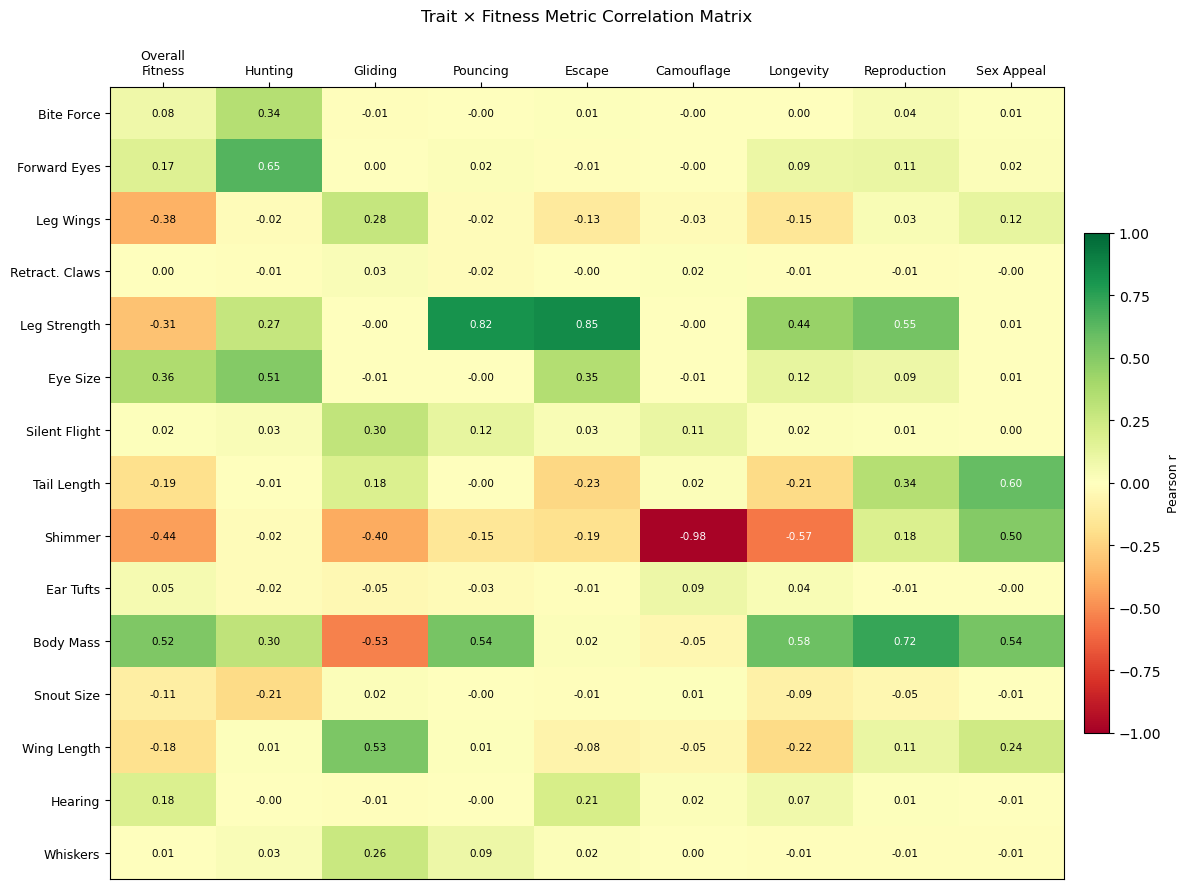

In [40]:
#This snippet is vibe-coded and works to plot a correlation matrix for the fitness function.

import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

random.seed(42)
N = 5000
population = create_population(N)

traits  = list(canon_microraptor.keys())
metrics = {
    'Overall\nFitness':  lambda r: r['fitness_score'],
    'Hunting':           lambda r: r['hunting_score']['hunting_value'],
    'Gliding':           lambda r: r['hunting_score']['gliding_approach'],
    'Pouncing':          lambda r: r['hunting_score']['pouncing_approach'],
    'Escape':            lambda r: r['escape_score']['escape_value'],
    'Camouflage':        lambda r: r['escape_score']['camouflage'],
    'Longevity':         lambda r: r['mortality_score']['mortality_value'],
    'Reproduction':      lambda r: r['reproductivity_score']['reproduction_value'],
    'Sex Appeal':        lambda r: r['reproductivity_score']['sex_appeal'],
}

results = [fitness(ind, stage_one) for ind in population]

trait_arr  = np.array([[ind[t] for t in traits] for ind in population])
metric_arr = np.array([[fn(r) for fn in metrics.values()] for r in results])

# Pearson r: traits (rows) x metrics (cols)
corr = np.corrcoef(trait_arr.T, metric_arr.T)
corr_block = corr[:len(traits), len(traits):]

trait_labels = {
    'bite_force':'Bite Force', 'forward_eyes':'Forward Eyes', 'leg_wings':'Leg Wings',
    'retractable_claws':'Retract. Claws', 'leg_strength':'Leg Strength', 'eye_size':'Eye Size',
    'silent_flight':'Silent Flight', 'tail_length':'Tail Length', 'shimmer':'Shimmer',
    'ear_tufts':'Ear Tufts', 'body_mass':'Body Mass', 'snout_size':'Snout Size',
    'wings_length':'Wing Length', 'hearing':'Hearing', 'whiskers':'Whiskers',
}

fig, ax = plt.subplots(figsize=(12, 9))
im = ax.imshow(corr_block, cmap='RdYlGn', vmin=-1, vmax=1, aspect='auto')

ax.set_xticks(range(len(metrics)))
ax.set_yticks(range(len(traits)))
ax.set_xticklabels(list(metrics.keys()), fontsize=9)
ax.set_yticklabels([trait_labels[t] for t in traits], fontsize=9)
ax.xaxis.set_label_position('top')
ax.xaxis.tick_top()

for r in range(len(traits)):
    for c in range(len(metrics)):
        v = corr_block[r, c]
        ax.text(c, r, f'{v:.2f}', ha='center', va='center',
                fontsize=7.5, color='black' if abs(v) < 0.55 else 'white')

plt.colorbar(im, ax=ax, fraction=0.025, pad=0.02).set_label('Pearson r', fontsize=9)
ax.set_title('Trait × Fitness Metric Correlation Matrix',
             fontsize=12, pad=20)
plt.tight_layout()
plt.savefig(
    r"C:\Users\A_mou\OneDrive\Desktop\Meowl Research Center\Figures\fitness_correlation_matrix.png"
)
print("Saved.")

Saved.


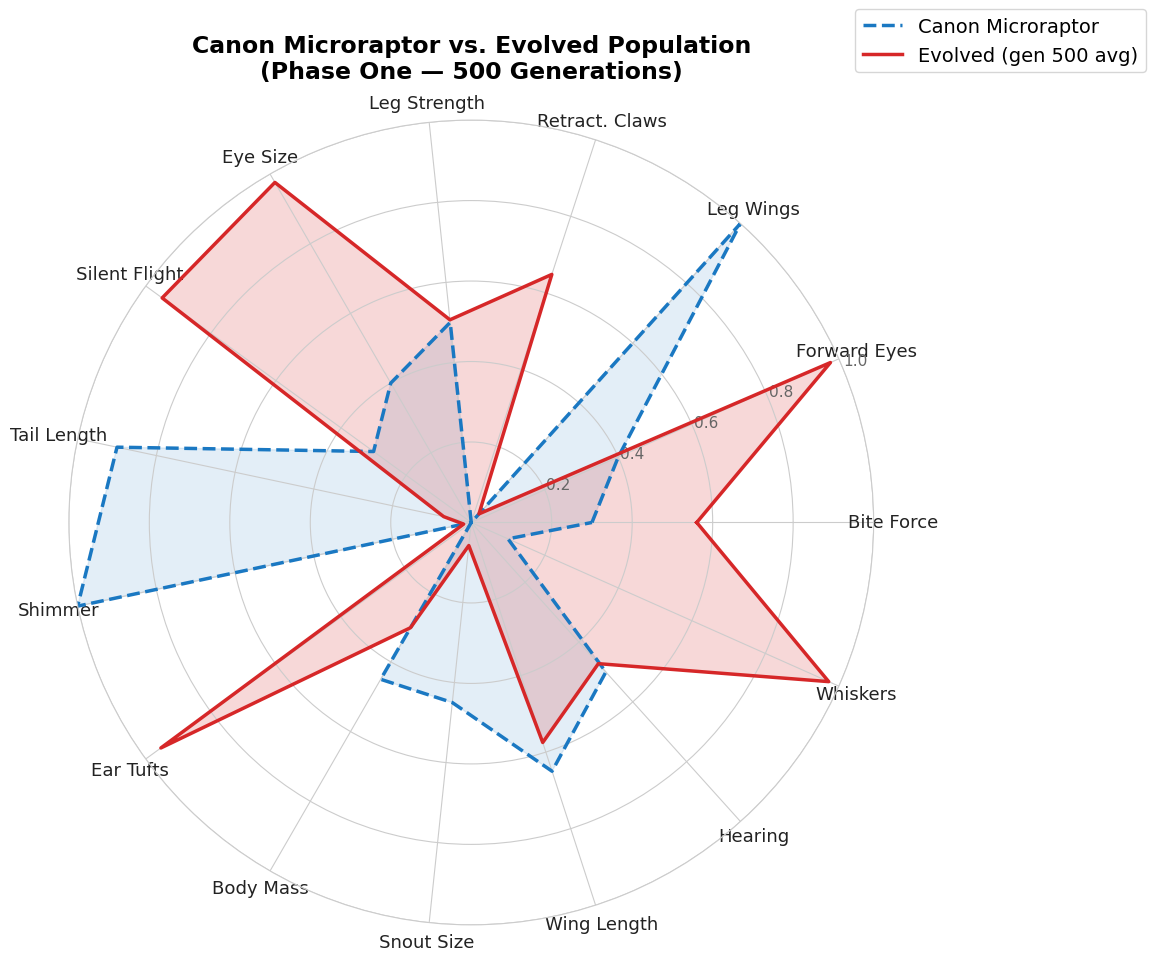

In [42]:
#This snippet is vibe-coded and works to plot a radar plot for the canon vs evolved traits after 500 generations of a population o 200
import random
import numpy as np
import matplotlib.pyplot as plt

random.seed(42)

NUM_GENERATIONS = 500
POPULATION_SIZE = 200

population = create_population(POPULATION_SIZE)
for gen in range(NUM_GENERATIONS):
    population = meowl_evolve(population, stage_one)

traits = list(canon_microraptor.keys())
evolved_avg = {t: np.mean([ind[t] for ind in population]) for t in traits}

trait_labels = {
    'bite_force':        'Bite Force',
    'forward_eyes':      'Forward Eyes',
    'leg_wings':         'Leg Wings',
    'retractable_claws': 'Retract. Claws',
    'leg_strength':      'Leg Strength',
    'eye_size':          'Eye Size',
    'silent_flight':     'Silent Flight',
    'tail_length':       'Tail Length',
    'shimmer':           'Shimmer',
    'ear_tufts':         'Ear Tufts',
    'body_mass':         'Body Mass',
    'snout_size':        'Snout Size',
    'wings_length':      'Wing Length',
    'hearing':           'Hearing',
    'whiskers':          'Whiskers',
}

labels  = [trait_labels[t] for t in traits]
canon   = [canon_microraptor[t] for t in traits]
evolved = [evolved_avg[t] for t in traits]

N = len(traits)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles  += angles[:1]
canon   += canon[:1]
evolved += evolved[:1]

fig, ax = plt.subplots(figsize=(12, 12), subplot_kw=dict(polar=True))

ax.set_facecolor('white')
fig.patch.set_facecolor('white')
ax.spines['polar'].set_color('#cccccc')
ax.grid(color='#cccccc', linewidth=0.8)

ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticklabels(['0.2', '0.4', '0.6', '0.8', '1.0'], color='#666666', fontsize=11)
ax.set_ylim(0, 1)

ax.plot(angles, canon, color='#1a78c2', linewidth=2.5, linestyle='--', label='Canon Microraptor')
ax.fill(angles, canon, color='#1a78c2', alpha=0.12)

ax.plot(angles, evolved, color='#d62728', linewidth=2.5, linestyle='-', label=f'Evolved (gen {NUM_GENERATIONS} avg)')
ax.fill(angles, evolved, color='#d62728', alpha=0.18)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels, fontsize=13, color='#222222')

ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15),
          fontsize=14, framealpha=0.8,
          labelcolor='black', facecolor='white', edgecolor='#cccccc')

ax.set_title('Canon Microraptor vs. Evolved Population\n(Phase One — 500 Generations)',
             fontsize=17, color='black', pad=30, fontweight='bold')

plt.tight_layout()
plt.savefig('meowl_radar.png', dpi=150, bbox_inches='tight', facecolor='white')
print("Saved.")